# Alpha-Tilt Diffraction Map

Tilt the sample from -30 to +30 degrees, track the same region in HAADF images, and acquire one BM-Ceta diffraction pattern at every angle.

### Run the servers

To run against the silicon lamella digital twin, start its Tango servers from the repository root:

```bash
uv run startup_scripts/run_servers.py --yaml configs/digital_twin_tilt.yaml
```

Use `uv run startup_scripts/run_servers.py` instead for the microscope.

### Imports

In [1]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import tango
from quantem.core.utils.imaging_utils import cross_correlation_shift
from tiled.client import from_uri

%matplotlib ipympl

### Ping servers

In [2]:
DB_HOST = "127.0.0.1"  # digital twin
# DB_HOST = "10.46.217.241"  # microscope
DB_PORT = 9094

os.environ["TANGO_HOST"] = f"{DB_HOST}:{DB_PORT}"

scan = tango.DeviceProxy("asyncroscopy/scan/default")
camera = tango.DeviceProxy("asyncroscopy/camera/default")
microscope = tango.DeviceProxy("asyncroscopy/instrument/default")
data = tango.DeviceProxy("asyncroscopy/data/default")
stage = tango.DeviceProxy("asyncroscopy/stage/default")

for proxy in [scan, camera, microscope, data, stage]:
    proxy.set_timeout_millis(120_000)
    proxy.ping()
    print(proxy.name(), proxy.state())

asyncroscopy/scan/default ON
asyncroscopy/camera/default ON
asyncroscopy/instrument/default ON
asyncroscopy/data/default ON
asyncroscopy/stage/default ON


### Set Tiled Client

In [3]:
config = json.loads(data.get_config())
client = from_uri(config.get("uri"))
print("Tiled keys:", list(client))

Tiled keys: ['stem_image_HAADF_20260617T113100890911.h5', 'spectrum_eds_20260617T113333863968.h5', 'spectrum_eds_20260617T113333946998.h5', 'spectrum_eds_20260617T113334018225.h5', 'spectrum_eds_20260617T113334090072.h5', 'spectrum_eds_20260617T113334158870.h5', 'stem_image_HAADF_20260619T193537178014.h5', 'stem_image_HAADF_20260619T193629581856.h5', 'diffraction_BM-Ceta_20260619T193631500749.h5', 'diffraction_BM-Ceta_20260619T193631852562.h5', 'diffraction_BM-Ceta_20260619T193635044869.h5', 'diffraction_BM-Ceta_20260619T193638201360.h5', 'diffraction_BM-Ceta_20260619T193641355383.h5', 'stem_image_HAADF_20260619T193755955267.h5', 'stem_image_HAADF_20260619T194030676929.h5', 'stem_image_HAADF_20260619T194736076730.h5', 'stem_image_HAADF_20260619T195116284309.h5', 'stem_image_HAADF_20260619T195724455994.h5', 'diffraction_BM-Ceta_20260619T195742736439.h5', 'diffraction_BM-Ceta_20260619T195810018189.h5', 'diffraction_BM-Ceta_20260619T195848501752.h5', 'diffraction_BM-Ceta_20260619T19590691

### Configure imaging and tilt

The stage must begin at zero alpha. `tracking_sign` converts image-correlation shifts to microscope image-shift directions; flip an element if that microscope axis moves away from the reference.

In [4]:
scan.dwell_time = 1e-6
scan.imsize = 256
scan.scan_region = [0, 0, 1, 1]
scan.output_format = ".h5"

camera.camera_detector = "BM-Ceta"
camera.imsize = 512
camera.exposure_time = 0.5
camera.readout_area = "Half"
camera.frame_combining = 1
camera.electron_counting = True
camera.output_format = ".h5"

field_of_view = 700e-9  # overview of the digital lamella
alpha_step = 6.0
tracking_sign = np.array([1.0, 1.0])
microscope.set_fov(field_of_view)

print("Screen current (pA):", microscope.get_screen_current())

Screen current (pA): 50.0


### Acquire the tracking reference

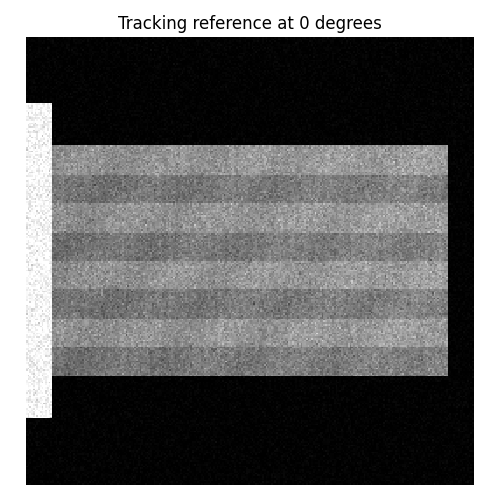

In [5]:
starting_stage = np.asarray(stage.position, dtype=float)
starting_image_shift = np.asarray(microscope.get_image_shift(), dtype=float)

if not np.isclose(starting_stage[3], 0.0):
    raise RuntimeError("Set the stage alpha to 0 degrees before continuing.")

reference_key = microscope.acquire_scanned_image(["haadf"])
reference_image = client[reference_key]["image"]["HAADF"].read()

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(reference_image, cmap="gray", interpolation="none")
ax.set_title("Tracking reference at 0 degrees")
ax.axis("off")
plt.tight_layout()

### Pre-tilt to -30 degrees

Approach the start of the tilt series in small steps while keeping the reference feature centered.

In [6]:
current_image_shift = starting_image_shift.copy()
pixel_size = field_of_view / scan.imsize
pretilt_angles = np.arange(-alpha_step, -30.0 - alpha_step / 2, -alpha_step)

try:
    for alpha in pretilt_angles:
        position = starting_stage.copy()
        position[3] = alpha
        stage.position = position.tolist()

        key = microscope.acquire_scanned_image(["haadf"])
        image = client[key]["image"]["HAADF"].read()
        row_shift, column_shift = cross_correlation_shift(
            reference_image, image, max_shift=scan.imsize / 4
        )
        correction = tracking_sign * np.array([column_shift, row_shift]) * pixel_size
        current_image_shift += correction
        microscope.set_image_shift(current_image_shift.tolist())
        print(f"alpha {alpha:5.1f} deg | correction {correction * 1e9} nm")
except Exception:
    stage.position = starting_stage.tolist()
    microscope.set_image_shift(starting_image_shift.tolist())
    raise

alpha  -6.0 deg | correction [ 0.01461748 11.80217266] nm
alpha -12.0 deg | correction [-2.84895746e-03  1.20182367e+01] nm
alpha -18.0 deg | correction [0.45060684 3.96329311] nm
alpha -24.0 deg | correction [0.42895019 1.26581336] nm
alpha -30.0 deg | correction [-0.30356061  6.13618834] nm


### Track and acquire the Ceta tilt series

The original stage position and image shift are restored even if acquisition stops with an error.

In [7]:
alpha_angles = np.arange(-30.0, 30.0 + alpha_step / 2, alpha_step)
camera_keys = []
diffraction_patterns = []
tracking_shifts = []

try:
    for alpha in alpha_angles:
        position = starting_stage.copy()
        position[3] = alpha
        stage.position = position.tolist()

        tracking_key = microscope.acquire_scanned_image(["haadf"])
        tracking_image = client[tracking_key]["image"]["HAADF"].read()
        row_shift, column_shift = cross_correlation_shift(
            reference_image, tracking_image, max_shift=scan.imsize / 4
        )
        correction = tracking_sign * np.array([column_shift, row_shift]) * pixel_size
        current_image_shift += correction
        microscope.set_image_shift(current_image_shift.tolist())
        tracking_shifts.append([row_shift, column_shift])

        camera_key = microscope.acquire_camera_image()
        camera_keys.append(camera_key)
        diffraction_patterns.append(client[camera_key]["image"].read())
        print(f"alpha {alpha:5.1f} deg -> {camera_key}")
finally:
    stage.position = starting_stage.tolist()
    microscope.set_image_shift(starting_image_shift.tolist())

alpha -30.0 deg -> diffraction_BM-Ceta_20260808T063427974630.h5
alpha -24.0 deg -> diffraction_BM-Ceta_20260808T063428560020.h5
alpha -18.0 deg -> diffraction_BM-Ceta_20260808T063429194027.h5
alpha -12.0 deg -> diffraction_BM-Ceta_20260808T063430002436.h5
alpha  -6.0 deg -> diffraction_BM-Ceta_20260808T063430888179.h5
alpha   0.0 deg -> diffraction_BM-Ceta_20260808T063431543728.h5
alpha   6.0 deg -> diffraction_BM-Ceta_20260808T063432207027.h5
alpha  12.0 deg -> diffraction_BM-Ceta_20260808T063433214488.h5
alpha  18.0 deg -> diffraction_BM-Ceta_20260808T063434675012.h5
alpha  24.0 deg -> diffraction_BM-Ceta_20260808T063435741800.h5
alpha  30.0 deg -> diffraction_BM-Ceta_20260808T063437600080.h5


### Mesh the diffraction patterns into a tilt map

Each detector row is integrated to make an alpha-versus-detector-position view through the diffraction stack. The full stack remains in `diffraction_stack`.

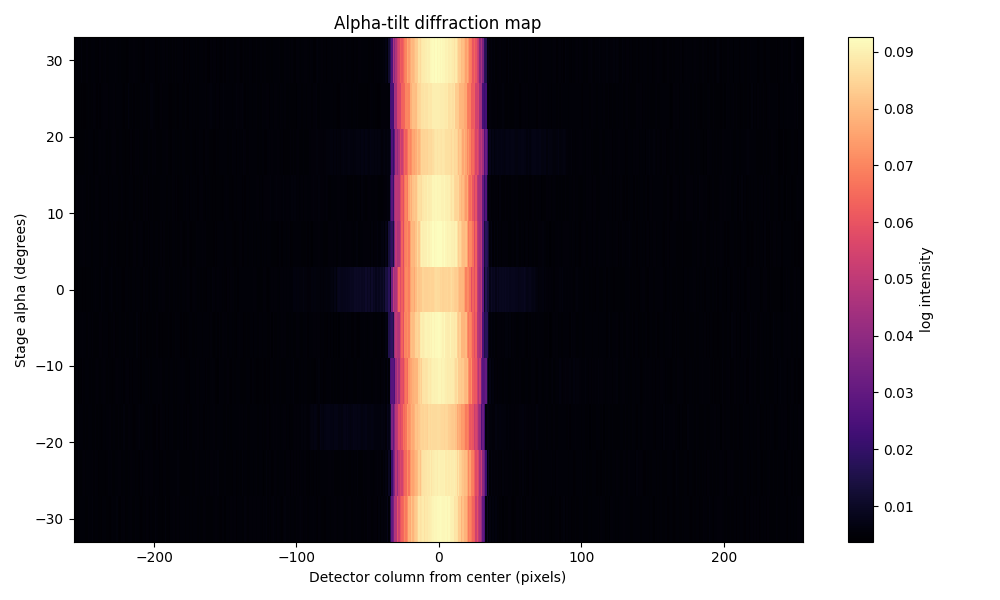

In [8]:
diffraction_stack = np.stack(diffraction_patterns)
tilt_map = np.log1p(diffraction_stack).mean(axis=1)
detector_x = np.arange(diffraction_stack.shape[-1]) - diffraction_stack.shape[-1] / 2
detector_mesh, alpha_mesh = np.meshgrid(detector_x, alpha_angles)

fig, ax = plt.subplots(figsize=(10, 6))
mesh = ax.pcolormesh(detector_mesh, alpha_mesh, tilt_map, cmap="magma", shading="auto")
ax.set_xlabel("Detector column from center (pixels)")
ax.set_ylabel("Stage alpha (degrees)")
ax.set_title("Alpha-tilt diffraction map")
fig.colorbar(mesh, ax=ax, label="log intensity")
plt.tight_layout()

### Inspect selected diffraction patterns

In [12]:
import matplotlib.colors as colors

Diffraction stack shape: (11, 512, 512)
Tracking shifts (row, column pixels):
[[ 2.71086454e-01 -1.13969564e-01]
 [-2.53835291e+00 -1.00535825e-01]
 [-1.51901725e+00  1.68511927e-01]
 [-2.53260809e+00  1.75224125e-01]
 [-2.68450934e+00  1.75935030e-01]
 [-4.93616841e+00  1.78174764e-01]
 [-4.74211660e+00  1.76451534e-01]
 [-5.55589733e+00 -3.43886882e-01]
 [-7.54387647e+00  1.62720218e-01]
 [-7.53697282e+00 -2.79985659e-04]
 [-6.68044481e+00 -1.08161218e-01]]


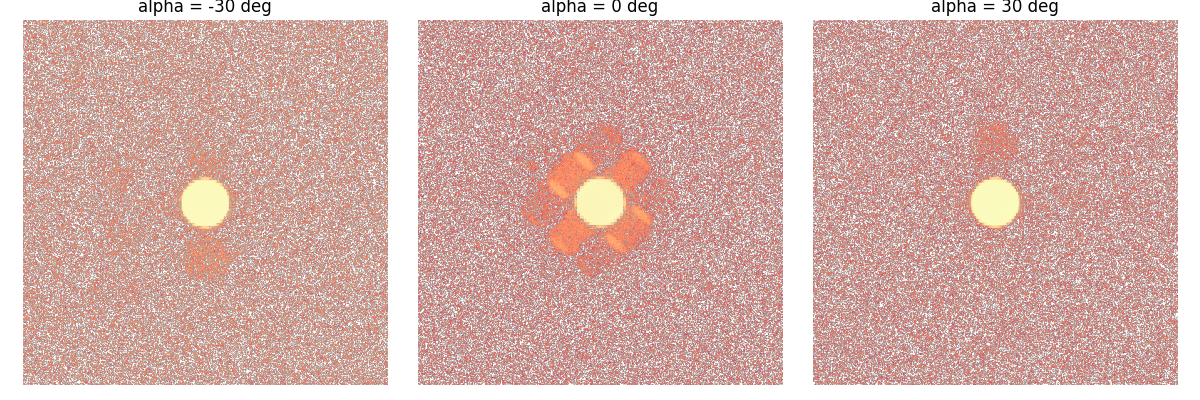

In [13]:
indices = [0, len(alpha_angles) // 2, len(alpha_angles) - 1]
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, index in zip(axes, indices):
    ax.imshow(np.log1p(diffraction_stack[index]), cmap="magma",)
    ax.set_title(f"alpha = {alpha_angles[index]:.0f} deg")
    ax.axis("off")
plt.tight_layout()

print("Diffraction stack shape:", diffraction_stack.shape)
print("Tracking shifts (row, column pixels):")
print(np.asarray(tracking_shifts))

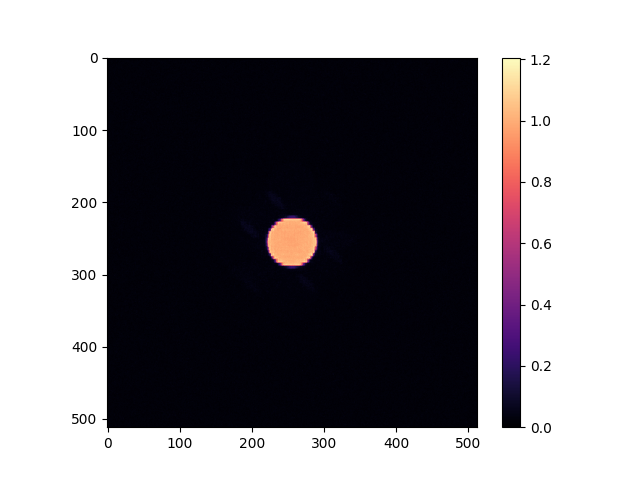

In [15]:
plt.figure()
plt.imshow(diffraction_stack.max(axis=0), cmap="magma")
plt.colorbar()
